### Necessary Imports

In [1]:
from astropy.table import Table
from common_functions import wavelets, plotter, reduce
import os
import pathlib
from pyasassn.client import SkyPatrolClient
import matplotlib.pyplot as plt

#### Now we'll use the stored rcparams.txt file to format our figure

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [3]:
client = SkyPatrolClient()

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.20 (11 SEPTEMBER 2025)
Please upgrade your client if not up to date.

We are reprocessing a number of lightcurves in database.
Once finished we should have more complete and higher quality photometry.
Thank you for your patience,
K. Hart (22 MAY 2025)




In [4]:
def pipeline(objid, minimum=False, scaled=False):
    """ Transform applied to an ASAS-SN star

    Args:
        objid (int): an ASAS-SN permanent identifier
        minimum (boolean): whether the transform should be min-masked instead of NaN-masked and then -> 0. (False is NaN mask)
        scaled (boolean):  whether the transform should be scaled 10x average power and capped at [0, 255] (False is not scaled 10x)

    Returns:
        saved_lc_fin (pyasassn.LightCurve): the reduced light curve as a pyasassn.LightCurve object
        
    """
    lightcurve_collection = client.query_list([objid], download=True)
    for lc in lightcurve_collection.itercurves():
        savedlc = lc
    savedlc_fin = reduce(savedlc)
    wavelet = wavelets(savedlc_fin, min=minimum, scale=scaled, tradeoff=2)
    plotter(wavelet)
    return(wavelet)

Pulled 1 of 1


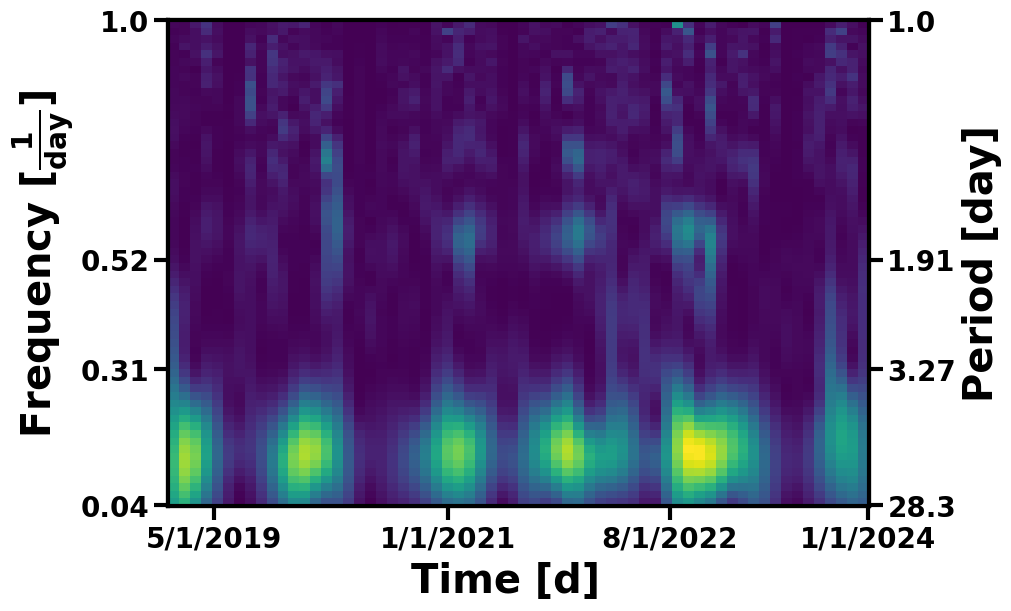

In [5]:
transform = pipeline(463856975202)